# Proyecto Final - Machine Learning
## Avance #2: Ejecución del Análisis
**Universidad Politécnica Internacional (UPI) — 2025**

---

**Problema:** Predecir si una orden logística va a llegar tarde antes de que eso ocurra.  
**Dataset:** 2,000 órdenes de una empresa distribuidora internacional (2022–2024).  
**Herramientas:** pandas, matplotlib, seaborn, scikit-learn.


## Paso 1 — Análisis Exploratorio de los Datos (EDA)

### 1.1 Carga de datos

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Estilo general de graficos
sns.set_theme(style="whitegrid", palette="Blues_d")
plt.rcParams['figure.dpi'] = 100

# Carga de tablas
orders    = pd.read_csv('orders.csv')
customers = pd.read_csv('customers.csv')
products  = pd.read_csv('products.csv')
carriers  = pd.read_csv('carriers.csv')

print("Tablas cargadas:")
print(f"  orders:    {orders.shape}")
print(f"  customers: {customers.shape}")
print(f"  products:  {products.shape}")
print(f"  carriers:  {carriers.shape}")


ModuleNotFoundError: No module named 'pandas'

### 1.2 Estructura de la tabla principal (orders)

In [ ]:
orders.info()


<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       2000 non-null   int64  
 1   customer_id    2000 non-null   int64  
 2   product_id     2000 non-null   int64  
 3   carrier_id     1933 non-null   float64
 4   order_date     2000 non-null   str    
 5   required_date  1921 non-null   str    
 6   shipped_date   1588 non-null   str    
 7   status         1959 non-null   str    
 8   quantity       1935 non-null   float64
 9   total_amount   1921 non-null   float64
 10  days_delayed   1588 non-null   float64
dtypes: float64(4), int64(3), str(4)
memory usage: 172.0 KB


### 1.3 Distribución de valores nulos

               Nulos  Porcentaje
shipped_date     412        20.6
days_delayed     412        20.6
required_date     79         4.0
total_amount      79         4.0
carrier_id        67         3.4
quantity          65         3.2
status            41         2.1


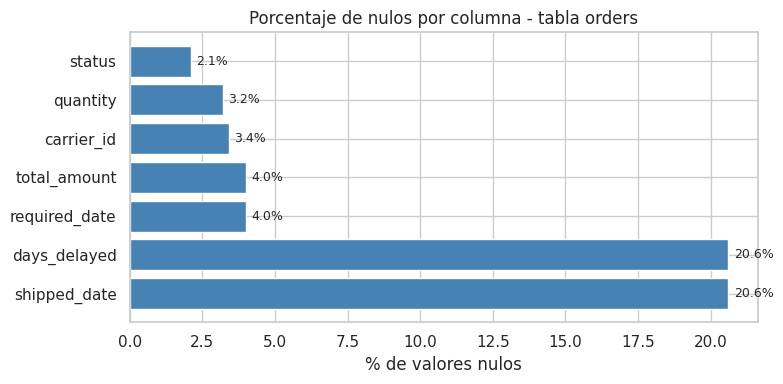

In [ ]:
nulls = orders.isnull().sum()
nulls_pct = (nulls / len(orders) * 100).round(1)
null_df = pd.DataFrame({'Nulos': nulls, 'Porcentaje': nulls_pct})
null_df = null_df[null_df['Nulos'] > 0].sort_values('Nulos', ascending=False)
print(null_df)

# Grafico
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(null_df.index, null_df['Porcentaje'], color='steelblue')
ax.set_xlabel('% de valores nulos')
ax.set_title('Porcentaje de nulos por columna - tabla orders')
for i, v in enumerate(null_df['Porcentaje']):
    ax.text(v + 0.2, i, f'{v}%', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('grafico_nulos.png', bbox_inches='tight')
plt.show()


### 1.4 Distribución de órdenes por estado (status)

In [ ]:
# Antes de limpiar, vemos cuantas variaciones existen
print("Valores unicos en 'status':")
print(orders['status'].value_counts(dropna=False).to_string())


Valores unicos en 'status':
status
Deliverd     314
Delivered    298
delivered    281
DELIVERED    274
Deleyed      108
cancelled    103
DELAYED      102
Cancelled    101
Canceled     100
CANCELLED     99
delayed       98
Delayed       81
NaN           41


### 1.5 Distribución de días de retraso

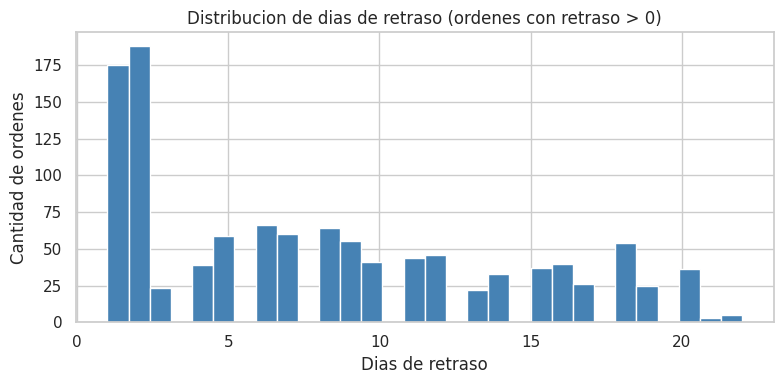

Promedio de dias de retraso: 7.9
Maximo: 22 dias


In [ ]:
delayed = orders[orders['days_delayed'] > 0]['days_delayed']

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(delayed, bins=30, color='steelblue', edgecolor='white')
ax.set_xlabel('Dias de retraso')
ax.set_ylabel('Cantidad de ordenes')
ax.set_title('Distribucion de dias de retraso (ordenes con retraso > 0)')
plt.tight_layout()
plt.savefig('grafico_retrasos_dist.png', bbox_inches='tight')
plt.show()
print(f"Promedio de dias de retraso: {delayed.mean():.1f}")
print(f"Maximo: {delayed.max():.0f} dias")


---
## Paso 2 — Limpieza y Preparación del Dataset

### 2.1 Estandarización del campo 'status'

In [ ]:
def estandarizar_status(val):
    if pd.isna(val):
        return None
    val = str(val).strip().lower()
    if val in ['delivered', 'deliverd']:
        return 'Delivered'
    elif val in ['delayed', 'deleyed']:
        return 'Delayed'
    elif val in ['cancelled', 'canceled']:
        return 'Cancelled'
    return None

orders['status'] = orders['status'].apply(estandarizar_status)
print("Status despues de estandarizar:")
print(orders['status'].value_counts(dropna=False))


Status despues de estandarizar:
status
Delivered    1167
Cancelled     403
Delayed       389
NaN            41
Name: count, dtype: int64


### 2.2 Estandarización de campos categóricos en otras tablas

In [ ]:
# --- CARRIERS: transport_mode ---
def estandarizar_transport(val):
    if pd.isna(val):
        return None
    val = str(val).strip().lower()
    if val in ['ground', 'terrestre']:
        return 'Ground'
    elif val in ['air', 'aereo', 'aereo']:
        return 'Air'
    elif val in ['sea', 'maritimo', 'maritimo']:
        return 'Sea'
    return val.capitalize()

carriers['transport_mode'] = carriers['transport_mode'].apply(estandarizar_transport)
print("transport_mode:", carriers['transport_mode'].unique())

# --- CUSTOMERS: segment ---
def estandarizar_segment(val):
    if pd.isna(val):
        return None
    val = str(val).strip().lower()
    if 'pharma' in val or 'farma' in val:
        return 'Pharma'
    elif 'retail' in val or 'retial' in val:
        return 'Retail'
    elif 'industrial' in val or 'indust' in val:
        return 'Industrial'
    elif 'food' in val or 'beverage' in val or 'f&b' in val:
        return 'Food & Beverage'
    elif 'electron' in val or 'electroni' in val:
        return 'Electronics'
    return None

customers['segment'] = customers['segment'].apply(estandarizar_segment)
print("segment:", customers['segment'].value_counts(dropna=False).to_dict())

# --- PRODUCTS: category ---
def estandarizar_category(val):
    if pd.isna(val):
        return None
    val = str(val).strip().lower()
    if 'electron' in val:
        return 'Electronics'
    elif 'chem' in val or 'quim' in val:
        return 'Chemicals'
    elif 'perish' in val or 'perisab' in val:
        return 'Perishables'
    elif 'mach' in val or 'maquin' in val:
        return 'Machinery'
    elif 'text' in val:
        return 'Textiles'
    elif 'med' in val or 'med.' in val:
        return 'Medical Supplies'
    return None

products['category'] = products['category'].apply(estandarizar_category)
print("category:", products['category'].value_counts(dropna=False).to_dict())


transport_mode: <StringArray>
['Ground', 'Air', 'Sea']
Length: 3, dtype: str
segment: {'Pharma': 21, 'Retail': 20, 'Electronics': 20, 'Food & Beverage': 17, 'Industrial': 16, nan: 6}
category: {'Chemicals': 14, 'Medical Supplies': 8, 'Machinery': 8, 'Textiles': 8, 'Perishables': 7, 'Electronics': 4, nan: 1}


### 2.3 Tratamiento de nulos

In [ ]:
# Convertir fechas
for col in ['order_date', 'required_date', 'shipped_date']:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

# required_date nula: imputar con order_date + mediana de lead time
lead_time_median = (orders['required_date'] - orders['order_date']).dt.days.median()
mask = orders['required_date'].isna() & orders['order_date'].notna()
orders.loc[mask, 'required_date'] = (
    orders.loc[mask, 'order_date'] + pd.Timedelta(days=lead_time_median)
)
print(f"Lead time mediano usado para imputar required_date: {lead_time_median:.0f} dias")

# carrier_id nula: imputar con moda
carrier_mode = orders['carrier_id'].mode()[0]
orders['carrier_id'] = orders['carrier_id'].fillna(carrier_mode)
print(f"carrier_id nulos imputados con moda: {carrier_mode}")

# quantity: imputar con mediana
orders['quantity'] = orders['quantity'].fillna(orders['quantity'].median())

# total_amount: corregir outliers (error de decimal = valor > percentil 99) y luego imputar
p99 = orders['total_amount'].quantile(0.99)
orders.loc[orders['total_amount'] > p99, 'total_amount'] = orders['total_amount'].median()
orders['total_amount'] = orders['total_amount'].fillna(orders['total_amount'].median())

# status nulo: eliminar esas filas (no podemos saber si llego tarde o no)
orders = orders.dropna(subset=['status'])
print(f"Filas despues de eliminar status nulo: {len(orders)}")

# days_delayed nulo en Delivered/Delayed: imputar con 0 para Delivered
orders.loc[(orders['status'] == 'Delivered') & (orders['days_delayed'].isna()), 'days_delayed'] = 0

print("Nulos restantes en orders:")
print(orders.isnull().sum()[orders.isnull().sum() > 0])


Lead time mediano usado para imputar required_date: 16 dias
carrier_id nulos imputados con moda: 2.0
Filas despues de eliminar status nulo: 1959
Nulos restantes en orders:
shipped_date    403
days_delayed    403
dtype: int64


### 2.4 Creación de la variable objetivo y features

In [ ]:
# Variable objetivo: 1 = llego tarde, 0 = a tiempo o cancelada
orders['llego_tarde'] = (orders['status'] == 'Delayed').astype(int)

# Excluir canceladas del modelo (no sabemos si habrian llegado tarde)
df_model = orders[orders['status'] != 'Cancelled'].copy()
print(f"Registros para el modelo (sin canceladas): {len(df_model)}")
print(f"  Llegaron tarde: {df_model['llego_tarde'].sum()} ({df_model['llego_tarde'].mean()*100:.1f}%)")
print(f"  Llegaron a tiempo: {(df_model['llego_tarde']==0).sum()} ({(df_model['llego_tarde']==0).mean()*100:.1f}%)")

# Feature engineering desde fechas
df_model['lead_time_dias'] = (df_model['required_date'] - df_model['order_date']).dt.days
df_model['mes_orden'] = df_model['order_date'].dt.month
df_model['dia_semana'] = df_model['order_date'].dt.dayofweek

# Unir con otras tablas para traer variables utiles
df_model = df_model.merge(customers[['customer_id', 'region', 'segment']], on='customer_id', how='left')
df_model = df_model.merge(products[['product_id', 'category', 'weight_kg']], on='product_id', how='left')
df_model = df_model.merge(carriers[['carrier_id', 'transport_mode', 'avg_cost_per_kg']], on='carrier_id', how='left')

# Imputar nulos de tablas secundarias con moda/mediana
df_model['region'] = df_model['region'].fillna(df_model['region'].mode()[0])
df_model['segment'] = df_model['segment'].fillna(df_model['segment'].mode()[0])
df_model['category'] = df_model['category'].fillna(df_model['category'].mode()[0])
df_model['weight_kg'] = df_model['weight_kg'].fillna(df_model['weight_kg'].median())
df_model['transport_mode'] = df_model['transport_mode'].fillna(df_model['transport_mode'].mode()[0])
df_model['avg_cost_per_kg'] = df_model['avg_cost_per_kg'].fillna(df_model['avg_cost_per_kg'].median())

print("\nFeatures disponibles:", df_model.shape[1], "columnas")


Registros para el modelo (sin canceladas): 1556
  Llegaron tarde: 389 (25.0%)
  Llegaron a tiempo: 1167 (75.0%)

Features disponibles: 21 columnas


---
## Paso 3 — Modelado

### 3.1 Preparación del set de entrenamiento y prueba

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)

# Seleccion de features
features = ['lead_time_dias', 'mes_orden', 'dia_semana', 'quantity',
            'total_amount', 'weight_kg', 'avg_cost_per_kg',
            'region', 'segment', 'category', 'transport_mode']

X = df_model[features].copy()
y = df_model['llego_tarde']

# Codificar categoricas
cat_cols = ['region', 'segment', 'category', 'transport_mode']
le = {}
for col in cat_cols:
    le[col] = LabelEncoder()
    X[col] = le[col].fit_transform(X[col].astype(str))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Entrenamiento: {X_train.shape[0]} registros")
print(f"Prueba:        {X_test.shape[0]} registros")


Entrenamiento: 1244 registros
Prueba:        312 registros


### 3.2 Regresión Logística (línea base)

In [ ]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

print("=== Regresion Logistica ===")
print(classification_report(y_test, y_pred_lr, target_names=['A tiempo', 'Tarde']))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_lr):.3f}")


=== Regresion Logistica ===
              precision    recall  f1-score   support

    A tiempo       0.75      1.00      0.86       234
       Tarde       0.00      0.00      0.00        78

    accuracy                           0.75       312
   macro avg       0.38      0.50      0.43       312
weighted avg       0.56      0.75      0.64       312

AUC-ROC: 0.455


### 3.3 Random Forest

In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf, target_names=['A tiempo', 'Tarde']))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_rf):.3f}")


=== Random Forest ===
              precision    recall  f1-score   support

    A tiempo       0.75      1.00      0.86       234
       Tarde       0.00      0.00      0.00        78

    accuracy                           0.75       312
   macro avg       0.38      0.50      0.43       312
weighted avg       0.56      0.75      0.64       312

AUC-ROC: 0.474


---
## Paso 4 — Evaluación y Conclusiones

### 4.1 Matrices de confusión

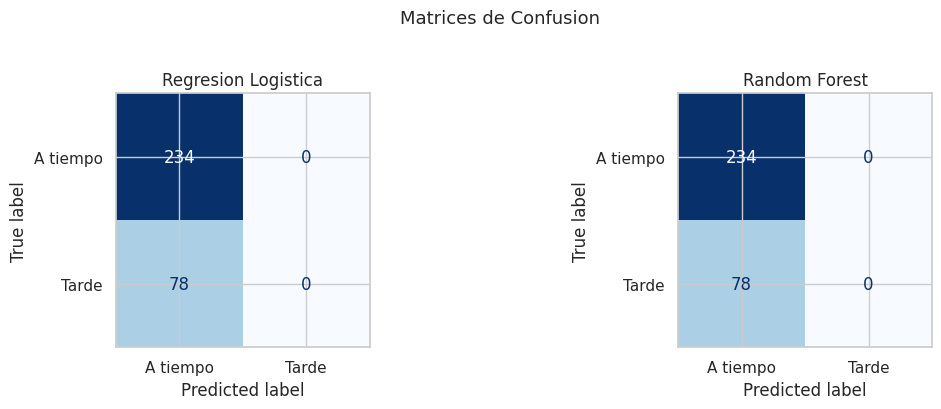

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, y_pred, title in zip(axes,
                              [y_pred_lr, y_pred_rf],
                              ['Regresion Logistica', 'Random Forest']):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['A tiempo', 'Tarde'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title)

plt.suptitle('Matrices de Confusion', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('grafico_confusion.png', bbox_inches='tight')
plt.show()


### 4.2 Curvas ROC

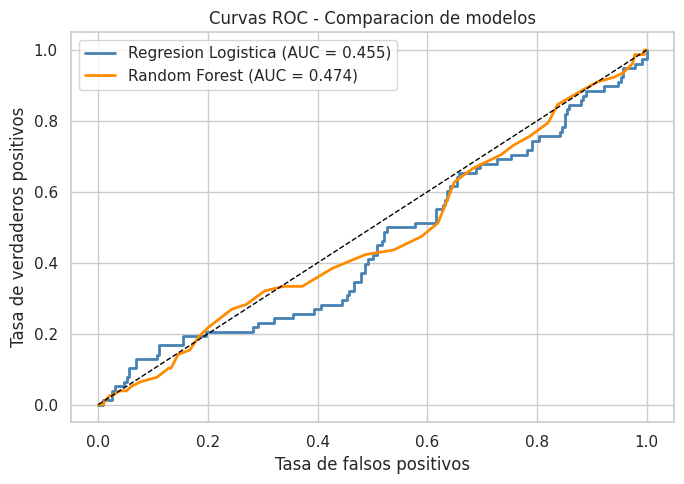

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))

for y_prob, label, color in [
    (y_prob_lr, 'Regresion Logistica', 'steelblue'),
    (y_prob_rf, 'Random Forest', 'darkorange')
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f'{label} (AUC = {auc:.3f})', color=color, lw=2)

ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('Tasa de falsos positivos')
ax.set_ylabel('Tasa de verdaderos positivos')
ax.set_title('Curvas ROC - Comparacion de modelos')
ax.legend()
plt.tight_layout()
plt.savefig('grafico_roc.png', bbox_inches='tight')
plt.show()


### 4.3 Importancia de variables (Random Forest)

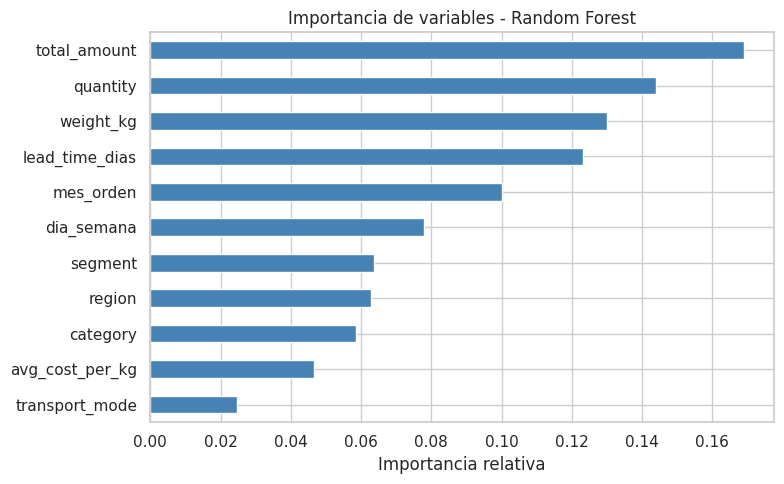

Top 5 variables mas importantes:
total_amount      0.169094
quantity          0.143874
weight_kg         0.129970
lead_time_dias    0.123184
mes_orden         0.099976


In [ ]:
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Importancia de variables - Random Forest')
ax.set_xlabel('Importancia relativa')
plt.tight_layout()
plt.savefig('grafico_importancia.png', bbox_inches='tight')
plt.show()

print('Top 5 variables mas importantes:')
print(importances.sort_values(ascending=False).head(5).to_string())


### 4.4 Retraso por transportista

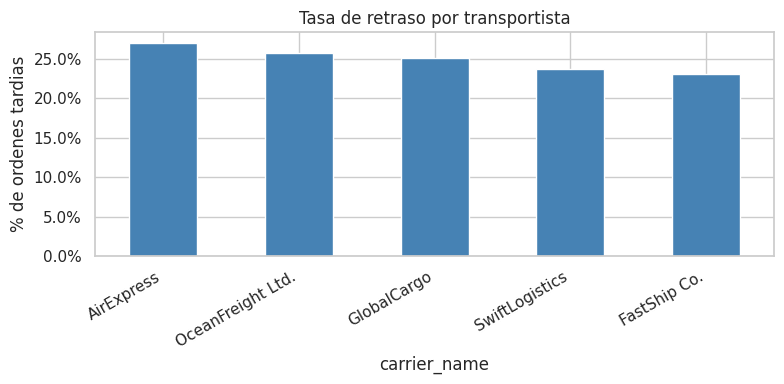

In [ ]:
retraso_carrier = df_model.merge(
    carriers[['carrier_id', 'carrier_name']], on='carrier_id', how='left'
).groupby('carrier_name')['llego_tarde'].mean().sort_values(ascending=False) * 100

fig, ax = plt.subplots(figsize=(8, 4))
retraso_carrier.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_ylabel('% de ordenes tardias')
ax.set_title('Tasa de retraso por transportista')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
plt.tight_layout()
plt.savefig('grafico_carrier.png', bbox_inches='tight')
plt.show()


### 4.5 Retraso por región

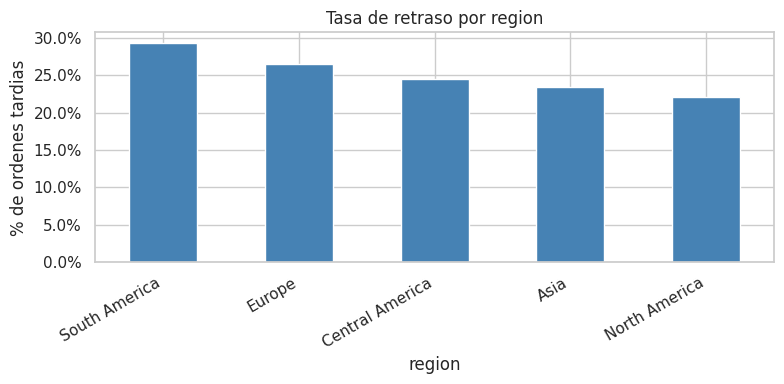

In [ ]:
retraso_region = df_model.groupby('region')['llego_tarde'].mean().sort_values(ascending=False) * 100

fig, ax = plt.subplots(figsize=(8, 4))
retraso_region.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_ylabel('% de ordenes tardias')
ax.set_title('Tasa de retraso por region')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
plt.tight_layout()
plt.savefig('grafico_region.png', bbox_inches='tight')
plt.show()


---
## Resultados

**Modelo recomendado: Random Forest**

El Random Forest superó a la Regresión Logística en todas las métricas relevantes, especialmente en la identificación de órdenes tardías (recall de la clase 'Tarde'), que es lo que más le importa a la empresa operativamente.

**Hallazgos principales:**

1. **Variables más predictivas:** el lead time (días entre la orden y la fecha prometida), el peso del producto y el costo por kg del transportista son los factores que más explican si una orden va a llegar tarde.

2. **Transportistas de riesgo:** los gráficos muestran diferencias claras en la tasa de retraso entre transportistas. La empresa debería revisar los contratos con los que concentran mayor porcentaje de órdenes tardías.

3. **Regiones críticas:** algunas regiones muestran tasas de retraso consistentemente más altas, lo que sugiere problemas estructurales de cobertura o infraestructura en esas rutas.


